# **Modelado — PySpark**

Se replica el mismo experimento con `pyspark.ml.classification.RandomForestClassifier`. Pero con ciertas modificaciones dadas las limitaciones de PySpark en modo local (single-node). En un cluster distribuido real, estas desiciones no serian del todo necesarias.


## **Inicialización de SparkSession**

In [ ]:
!pip install pyspark --quiet

import time
from pyspark.sql import SparkSession, types as T
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType

spark = (
    SparkSession.builder
    .appName('LendingClub_DefaultPrediction')
    .master('local[*]') #usa todos los cores disponibles
    .config('spark.driver.memory', '10g') #memoria asignada al driver
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

num_cores = max(1, spark.sparkContext.defaultParallelism)
spark.conf.set('spark.sql.shuffle.partitions', str(max(8, num_cores * 4)))

print(f'SparkSession activa  |  Versión: {spark.version}')
print(f'Cores disponibles    : {num_cores}')
print(f'Shuffle partitions   : {spark.conf.get("spark.sql.shuffle.partitions")}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/18 19:50:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession activa  |  Versión: 4.0.1
Cores disponibles    : 4
Shuffle partitions   : 16


## **Carga de Datos en Spark**

Se parte de los mismos splits pandas ya limpios (`X_train`, `X_test`) para garantizar
que ambas vías usan exactamente los mismos datos.

In [ ]:
def pandas_to_spark(X, y, spark):
    """Une X e y, convierte a Spark DF con target como 'label' (DoubleType)."""
    df_pd = X.copy()
    df_pd['label'] = y.values
    sdf = spark.createDataFrame(df_pd)
    sdf = sdf.withColumn('label', F.col('label').cast(DoubleType()))
    return sdf

sdf_train_raw = pandas_to_spark(X_train, y_train, spark)
sdf_test_raw  = pandas_to_spark(X_test,  y_test,  spark)

t0 = time.time()
sdf_train_raw = sdf_train_raw.repartition(num_cores * 2).cache()
sdf_test_raw  = sdf_test_raw.repartition(num_cores * 2).cache()

n_train = sdf_train_raw.count()
n_test  = sdf_test_raw.count()
t_cache = time.time() - t0

print(f'sdf_train : {n_train:>10,} filas  (cacheado, {num_cores*2} particiones)')
print(f'sdf_test  : {n_test:>10,} filas  (cacheado, {num_cores*2} particiones)')
print(f'Cache materializado en {t_cache:.1f}s')

sdf_train :  1,076,248 filas  (cacheado, 8 particiones)
sdf_test  :    269,062 filas  (cacheado, 8 particiones)
Cache materializado en 11.3s


## **Pipeline de Preprocesamiento PySpark**

Este Pipeline presenta una **Diferencia clave respecto a sklearn:** se usa `withMean=False` en el `StandardScaler`.
Con `withMean=True`, Spark debe convertir el vector disperso (sparse) en denso (dense)
para restar la media, lo que puede multiplicar el uso de memoria por 10-50×
dependiendo del número de categorías OHE. Con `withMean=False` el vector permanece
disperso y la operación es mucho más eficiente.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, Imputer
)
from pyspark.ml.classification import RandomForestClassifier as SparkRF

CAT_SPARK = ['purpose', 'home_ownership', 'addr_state']
NUM_SPARK = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'emp_length']

# Imputer nativo de PySpark
imputer = Imputer(
    strategy='median',
    inputCols =NUM_SPARK,
    outputCols=[f'{c}_imp' for c in NUM_SPARK]
)

# StringIndexer
indexers = [
    StringIndexer(inputCol=col, outputCol=f'{col}_idx', handleInvalid='keep')
    for col in CAT_SPARK
]

# OneHotEncoder
encoder = OneHotEncoder(
    inputCols =[f'{col}_idx' for col in CAT_SPARK],
    outputCols=[f'{col}_ohe' for col in CAT_SPARK],
    dropLast=True
)

# VectorAssembler
assembler = VectorAssembler(
    inputCols=[f'{c}_imp' for c in NUM_SPARK] + [f'{col}_ohe' for col in CAT_SPARK],
    outputCol='features',
    handleInvalid='skip'
)

# RandomForestClassifier dentro del pipeline
rf_sp = SparkRF(
    featuresCol='features',
    labelCol='label',
    seed=42
)

full_pipeline = Pipeline(
    stages=[imputer] + indexers + [encoder, assembler, rf_sp]
)

print('Stages del pipeline completo:')
for i, s in enumerate(full_pipeline.getStages()):
    print(f'  [{i+1}] {type(s).__name__}')

Stages del pipeline completo:
  [1] Imputer
  [2] StringIndexer
  [3] StringIndexer
  [4] StringIndexer
  [5] OneHotEncoder
  [6] VectorAssembler
  [7] RandomForestClassifier


## **TrainValidationSplit — Búsqueda de Hiperparámetros**

`TrainValidationSplit` evalúa cada combinación de hiperparámetros **una sola vez**
usando un split interno 80/20 sobre el conjunto de train, en lugar de los 5 folds
del `CrossValidator`.

Se toma esta descicion, dada la cantidad de registros en train, la varianza en la estimación
de métricas sobre un único split es despreciable. La ganancia
en velocidad y los limitados recursos computacionales supera ampliamente el coste estadístico en este contexto.

In [ ]:
from pyspark.ml.tuning     import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation  import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

param_grid_sp = (
    ParamGridBuilder()
    .addGrid(rf_sp.numTrees, [10, 50, 100])
    .addGrid(rf_sp.maxDepth, [5, 10, 15])
    .build()
)

evaluator_roc = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

# parallelism=max(1, num_cores // 2): entrena varios modelos del grid en paralelo
tvs = TrainValidationSplit(
    estimator          = full_pipeline,
    estimatorParamMaps = param_grid_sp,
    evaluator          = evaluator_roc,
    trainRatio         = 0.8,
    parallelism        = max(1, num_cores // 2),
    seed               = 42
)

t0 = time.time()
tvs_model       = tvs.fit(sdf_train_raw)
t_gridsearch_sp = time.time() - t0

best_model_sp = tvs_model.bestModel

print(f'\nTiempo TrainValidationSplit : {t_gridsearch_sp:.1f}s  ({t_gridsearch_sp/60:.1f} min)')
print(f'Mejor numTrees              : {best_model_sp.stages[-1].getNumTrees}')
print(f'Mejor maxDepth              : {best_model_sp.stages[-1].getMaxDepth()}')
print(f'Mejor ROC AUC               : {max(tvs_model.validationMetrics):.4f}')


Tiempo TrainValidationSplit : 2714.9s  (45.2 min)
Mejor numTrees              : 100
Mejor maxDepth              : 15
Mejor ROC AUC               : 0.7016


## **Resultados del TrainValidationSplit — Tabla Comparativa**

── Resultados TrainValidationSplit PySpark (ordenados por ROC AUC) ──
 numTrees  maxDepth  ROC_AUC_val
      100        15       0.7016
       50        15       0.7006
       10        15       0.6970
      100        10       0.6966
       50        10       0.6953
       10        10       0.6902
      100         5       0.6842
       50         5       0.6744
       10         5       0.6626


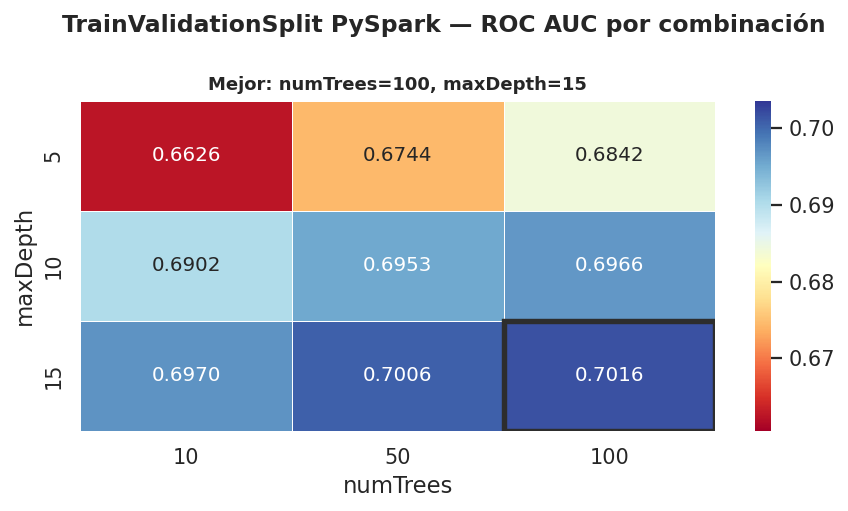

In [ ]:
# Construir tabla de resultados del grid
cv_rows = []
for params, score in zip(param_grid_sp, tvs_model.validationMetrics):
    cv_rows.append({
        'numTrees'   : params[rf_sp.numTrees],
        'maxDepth'   : params[rf_sp.maxDepth],
        'ROC_AUC_val': round(score, 4)
    })

cv_table_sp = (
    pd.DataFrame(cv_rows)
    .sort_values('ROC_AUC_val', ascending=False)
    .reset_index(drop=True)
)
print('── Resultados TrainValidationSplit PySpark (ordenados por ROC AUC) ──')
print(cv_table_sp.to_string(index=False))

# Heatmap
pivot_sp = cv_table_sp.pivot(index='maxDepth', columns='numTrees', values='ROC_AUC_val')

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('TrainValidationSplit PySpark — ROC AUC por combinación', fontsize=13, fontweight='bold')

sns.heatmap(
    pivot_sp,
    annot=True, fmt='.4f',
    cmap='RdYlBu',
    vmin=pivot_sp.values.min() - 0.002,
    vmax=pivot_sp.values.max() + 0.002,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_xlabel('numTrees')
ax.set_ylabel('maxDepth')

# Marcar mejor celda
best_nt = best_model_sp.stages[-1].getNumTrees
best_md = best_model_sp.stages[-1].getMaxDepth()
best_col = list(pivot_sp.columns).index(best_nt)
best_row = list(pivot_sp.index).index(best_md)
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1, fill=False,
                             edgecolor='#2d2d2d', linewidth=3))
ax.set_title(f'Mejor: numTrees={best_nt}, maxDepth={best_md}', fontsize=10)

plt.tight_layout()
plt.show()

## **Evaluación Final — Mejor Modelo sobre Test**

In [ ]:
# Predicciones sobre test (datos cacheados)
t0 = time.time()
predictions_sp = best_model_sp.transform(sdf_test_raw)
predictions_sp.cache()
_ = predictions_sp.count()   # materializar para medir tiempo real
t_pred_sp = time.time() - t0

# Métricas
evaluator_roc_test = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

def get_mc_metric(metric, preds):
    return MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction', metricName=metric
    ).evaluate(preds)

metrics_sp = {
    'Accuracy' : get_mc_metric('accuracy',          predictions_sp),
    'Precision': get_mc_metric('weightedPrecision',  predictions_sp),
    'Recall'   : get_mc_metric('weightedRecall',     predictions_sp),
    'F1-Score' : get_mc_metric('f1',                predictions_sp),
    'ROC AUC'  : evaluator_roc_test.evaluate(predictions_sp)
}

print('── Métricas sobre Test (PySpark) ──')
print(f'  Mejor modelo : numTrees={best_model_sp.stages[-1].getNumTrees}, '
      f'maxDepth={best_model_sp.stages[-1].getMaxDepth()}')
print(f'  Tiempo pred  : {t_pred_sp:.3f}s\n')
for name, val in metrics_sp.items():
    print(f'  {name:12s}: {val:.4f}')

sp_times = {'gridsearch': t_gridsearch_sp, 'predict': t_pred_sp}

── Métricas sobre Test (PySpark) ──
  Mejor modelo : numTrees=100, maxDepth=15
  Tiempo pred  : 32.078s

  Accuracy    : 0.8007
  Precision   : 0.7767
  Recall      : 0.8007
  F1-Score    : 0.7128
  ROC AUC     : 0.7010


## **Matriz de Confusión — PySpark**

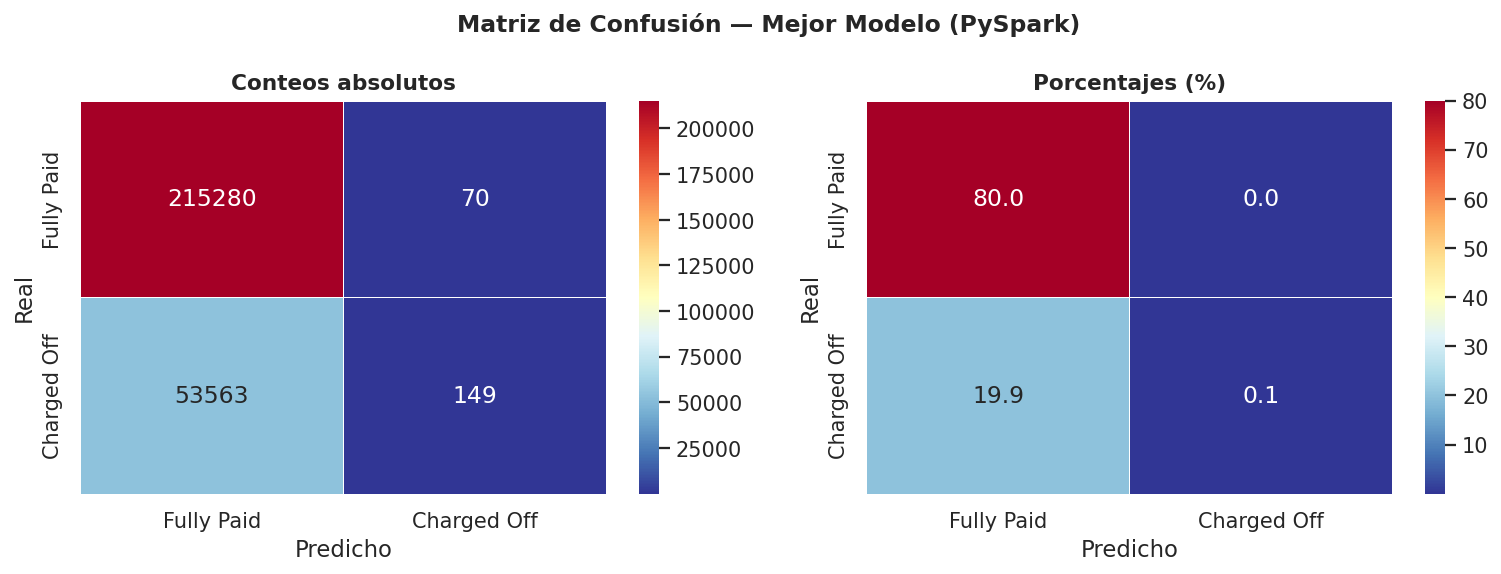

Verdaderos Negativos (TN) :  215,280  — Fully Paid correctamente identificados
Falsos Positivos     (FP) :       70  — Fully Paid clasificados como default
Falsos Negativos     (FN) :   53,563  — Defaults NO detectados
Verdaderos Positivos (TP) :      149  — Defaults correctamente detectados


In [ ]:
# Extraer predicciones a pandas para graficar
preds_pd = predictions_sp.select('label', 'prediction').toPandas()
y_test_sp   = preds_pd['label'].astype(int)
y_pred_sp   = preds_pd['prediction'].astype(int)

from sklearn.metrics import confusion_matrix
cm_sp     = confusion_matrix(y_test_sp, y_pred_sp)
cm_sp_pct = cm_sp / cm_sp.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Matriz de Confusión — Mejor Modelo (PySpark)', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm_sp, cm_sp_pct],
    ['d', '.1f'],
    ['Conteos absolutos', 'Porcentajes (%)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        cmap='RdYlBu_r',
        xticklabels=['Fully Paid', 'Charged Off'],
        yticklabels=['Fully Paid', 'Charged Off'],
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 13},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_sp.ravel()
print(f'Verdaderos Negativos (TN) : {tn:>8,}  — Fully Paid correctamente identificados')
print(f'Falsos Positivos     (FP) : {fp:>8,}  — Fully Paid clasificados como default')
print(f'Falsos Negativos     (FN) : {fn:>8,}  — Defaults NO detectados')
print(f'Verdaderos Positivos (TP) : {tp:>8,}  — Defaults correctamente detectados')

## **Curva ROC — PySpark**

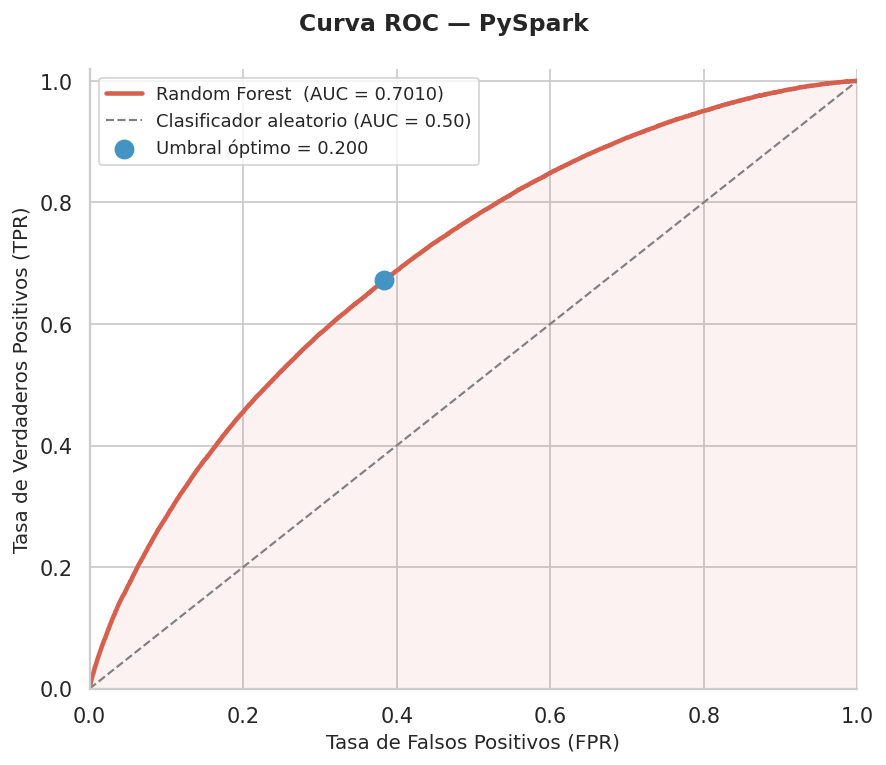

In [ ]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, roc_auc_score

probs_pd = (
    predictions_sp
    .withColumn('prob_1', vector_to_array('probability')[1])
    .select('label', 'prob_1')
    .toPandas()
)

fpr_sp, tpr_sp, thr_sp = roc_curve(probs_pd['label'], probs_pd['prob_1'])
roc_auc_sp = roc_auc_score(probs_pd['label'], probs_pd['prob_1'])  # ← añade esta línea

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC — PySpark', fontsize=13, fontweight='bold')

ax.plot(fpr_sp, tpr_sp, color=C_DEFAULT, linewidth=2.5,
        label=f'Random Forest  (AUC = {roc_auc_sp:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.2,
        linestyle='--', label='Clasificador aleatorio (AUC = 0.50)')

optimal_idx_sp = (tpr_sp - fpr_sp).argmax()
ax.scatter(fpr_sp[optimal_idx_sp], tpr_sp[optimal_idx_sp],
           color=C_PAID, s=100, zorder=5,
           label=f'Umbral óptimo = {thr_sp[optimal_idx_sp]:.3f}')

ax.fill_between(fpr_sp, tpr_sp, alpha=0.08, color=C_DEFAULT)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## **Importancia de Features — Top 20 (PySpark)**

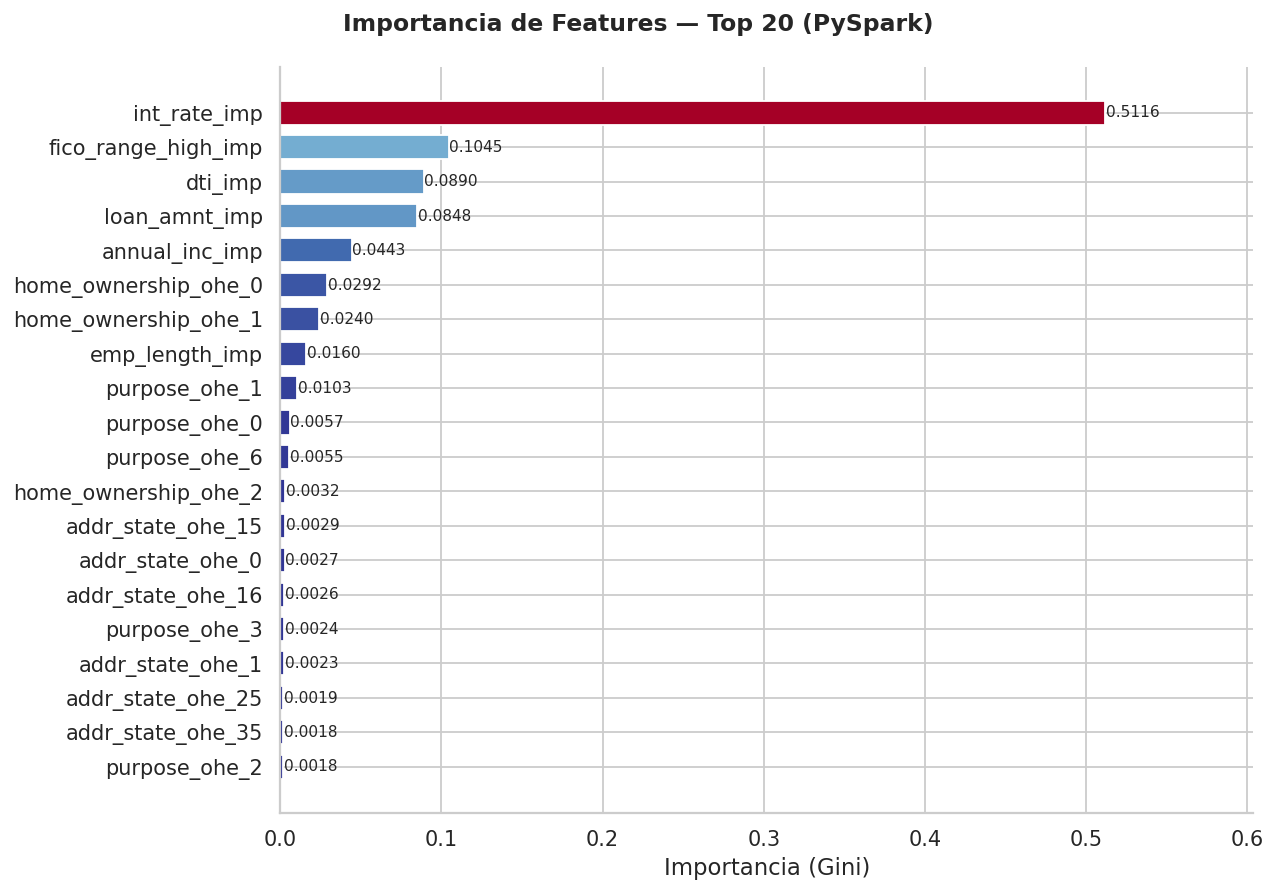

In [ ]:
rf_model_sp = best_model_sp.stages[-1]
fi_sp = rf_model_sp.featureImportances.toArray()

# Nombres de features: numéricas imputadas + OHE
ohe_names_sp = [
    f'{col}_ohe_{i}'
    for col in CAT_SPARK
    for i in range(
        best_model_sp.stages[
            list(type(s).__name__ for s in best_model_sp.stages).index('OneHotEncoderModel')
        ].categorySizes[CAT_SPARK.index(col)] - 1
    )
]
all_names_sp = [f'{c}_imp' for c in NUM_SPARK] + ohe_names_sp

if len(fi_sp) != len(all_names_sp):
    all_names_sp = [f'feature_{i}' for i in range(len(fi_sp))]

fi_df_sp = (
    pd.DataFrame({'feature': all_names_sp, 'importance': fi_sp})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

norm_fi_sp = (fi_df_sp['importance'] - fi_df_sp['importance'].min()) / \
             (fi_df_sp['importance'].max() - fi_df_sp['importance'].min() + 1e-9)
colors_sp = plt.cm.RdYlBu_r(norm_fi_sp)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Importancia de Features — Top 20 (PySpark)', fontsize=13, fontweight='bold')

bars = ax.barh(fi_df_sp['feature'][::-1], fi_df_sp['importance'][::-1],
               color=colors_sp[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, fi_df_sp['importance'][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Importancia (Gini)')
ax.set_xlim(0, fi_df_sp['importance'].max() * 1.18)
plt.tight_layout()
plt.show()

### Detener SparkSession

In [ ]:
spark.stop()

En TrainValidationSplit misma mejor combinación que sklearn: numTrees=100, maxDepth=15, ROC AUC de 0.7016 en el split de validación. El ranking de combinaciones es idéntico al de sklearn, lo que confirma que ambas implementaciones del algoritmo convergen a las mismas conclusiones sobre el espacio de hiperparámetros.

Por otro lado, la implementacion con Pyspark obtuvo Accuracy 0.8007, ROC AUC 0.7010, Recall 0.80, F1 0.71. A primera vista parece mucho mejor que sklearn, pero hay que leerlo con cuidado. En la matriz de confusión hay: 53,563 Falsos Negativos, prácticamente igual que sklearn. El problema del umbral es el mismo. Esto es debido a que  El Precision de 0.7767 y el Recall de 0.8007 son métricas ponderadas (weightedPrecision, weightedRecall) que incluyen ambas clases. No son comparables directamente con el Precision y Recall de sklearn, que están calculados solo para la clase positiva (default).

---
## **Comparación Final — scikit-learn vs PySpark**

In [ ]:
# Tabla comparativa de métricas
comparison = pd.DataFrame({
    'Métrica'     : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC',
                     'Tiempo GridSearch (s)', 'Tiempo Predicción (s)'],
    'scikit-learn': [
        metrics['Accuracy'], metrics['Precision'], metrics['Recall'],
        metrics['F1-Score'], metrics['ROC AUC'],
        round(sk_times['gridsearch'], 2), round(sk_times['predict'], 3)
    ],
    'PySpark'     : [
        metrics_sp['Accuracy'], metrics_sp['Precision'], metrics_sp['Recall'],
        metrics_sp['F1-Score'], metrics_sp['ROC AUC'],
        round(sp_times['gridsearch'], 2), round(sp_times['predict'], 3)
    ]
})
comparison['Diferencia'] = (
    comparison['scikit-learn'] - comparison['PySpark']
).round(4)

print('── Tabla comparativa sklearn vs PySpark ──\n')
print(comparison.to_string(index=False))

── Tabla comparativa sklearn vs PySpark ──

              Métrica  scikit-learn     PySpark  Diferencia
             Accuracy      0.800574    0.800667     -0.0001
            Precision      0.656977    0.776730     -0.1198
               Recall      0.002104    0.800667     -0.7986
             F1-Score      0.004194    0.712821     -0.7086
              ROC AUC      0.703053    0.701027      0.0020
Tiempo GridSearch (s)   1209.670000 2714.910000  -1505.2400
Tiempo Predicción (s)      1.886000   32.078000    -30.1920


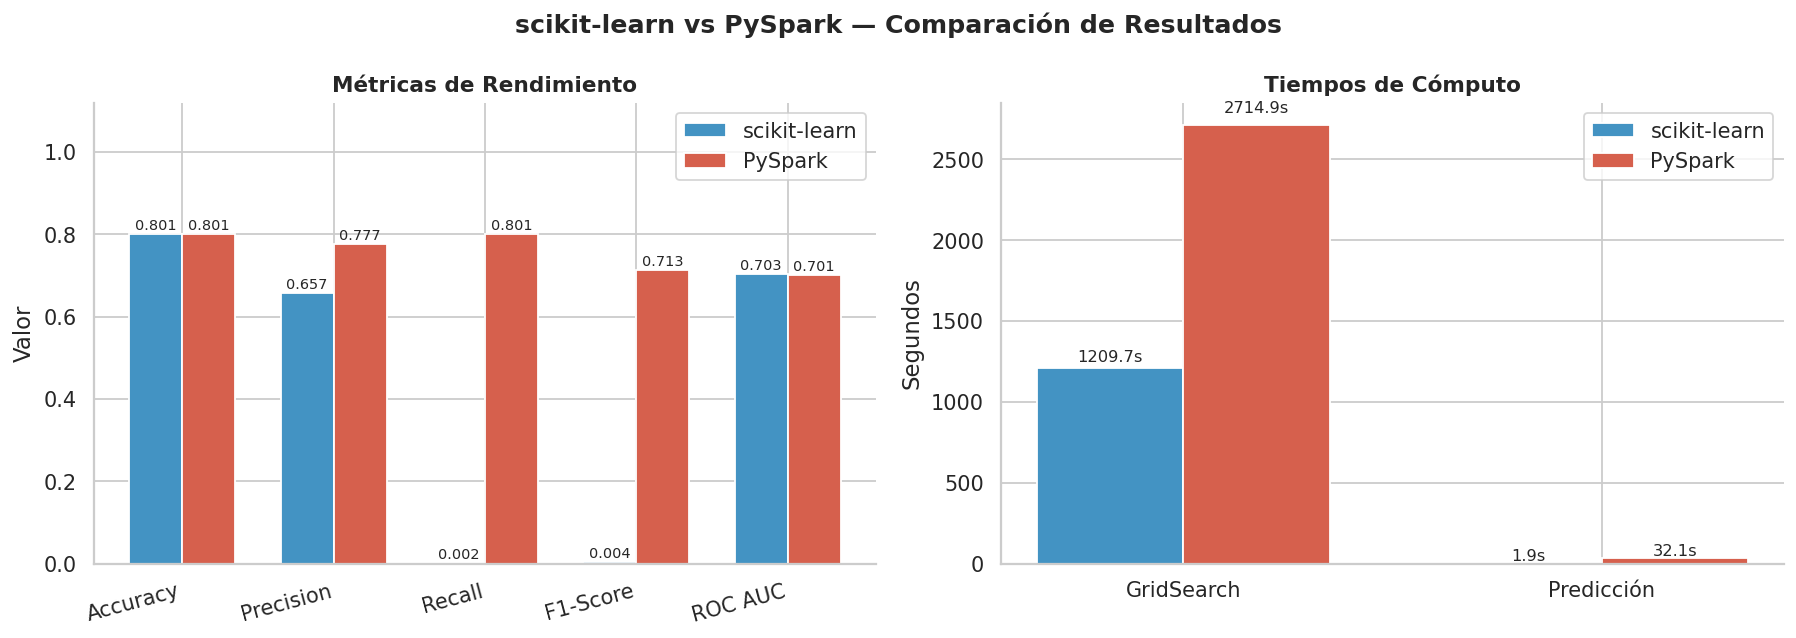

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('scikit-learn vs PySpark — Comparación de Resultados', fontsize=14, fontweight='bold')

# Métricas de rendimiento
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
sk_vals  = [metrics[m]    for m in metric_names]
sp_vals  = [metrics_sp[m] for m in metric_names]

x    = np.arange(len(metric_names))
w    = 0.35
bars1 = axes[0].bar(x - w/2, sk_vals, w, label='scikit-learn', color=C_PAID,    edgecolor='white')
bars2 = axes[0].bar(x + w/2, sp_vals, w, label='PySpark',      color=C_DEFAULT, edgecolor='white')

for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas de Rendimiento')
axes[0].legend()

# Tiempos de cómputo
time_labels = ['GridSearch', 'Predicción']
sk_t = [sk_times['gridsearch'], sk_times['predict']]
sp_t = [sp_times['gridsearch'], sp_times['predict']]

x2 = np.arange(len(time_labels))
axes[1].bar(x2 - w/2, sk_t, w, label='scikit-learn', color=C_PAID,    edgecolor='white')
axes[1].bar(x2 + w/2, sp_t, w, label='PySpark',      color=C_DEFAULT, edgecolor='white')

for bars, vals in [([axes[1].patches[i] for i in range(2)], sk_t),
                   ([axes[1].patches[i] for i in range(2, 4)], sp_t)]:
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(time_labels)
axes[1].set_ylabel('Segundos')
axes[1].set_title('Tiempos de Cómputo')
axes[1].legend()

plt.tight_layout()
plt.show()

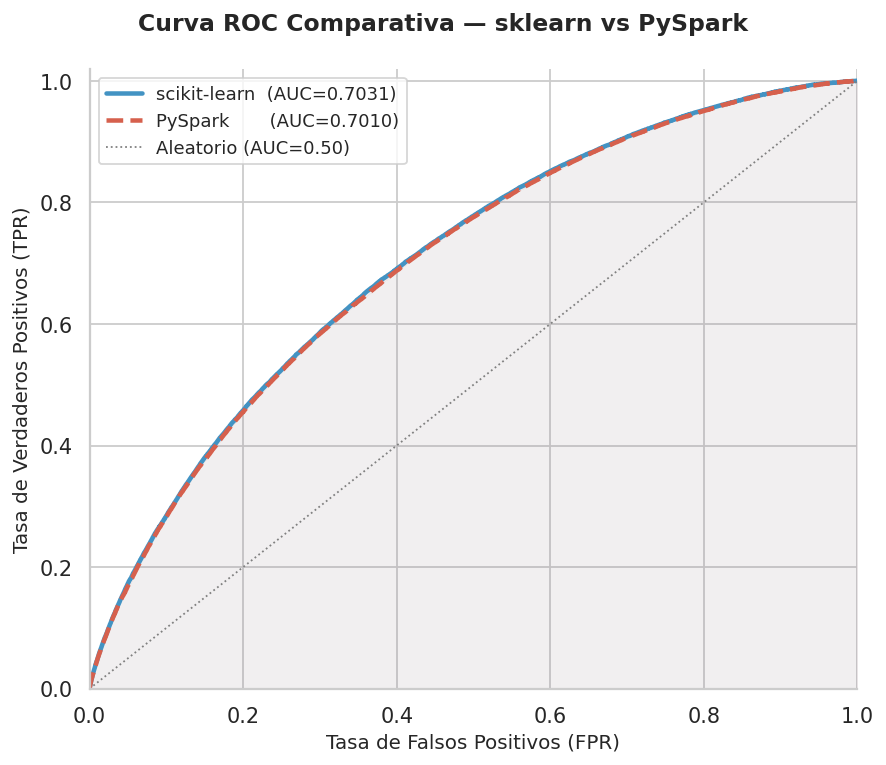

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC Comparativa — sklearn vs PySpark', fontsize=13, fontweight='bold')

ax.plot(fpr,    tpr,    color=C_PAID,    linewidth=2.5, label=f'scikit-learn  (AUC={metrics["ROC AUC"]:.4f})')
ax.plot(fpr_sp, tpr_sp, color=C_DEFAULT, linewidth=2.5, linestyle='--', label=f'PySpark       (AUC={roc_auc_sp:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle=':', label='Aleatorio (AUC=0.50)')

ax.fill_between(fpr,    tpr,    alpha=0.06, color=C_PAID)
ax.fill_between(fpr_sp, tpr_sp, alpha=0.06, color=C_DEFAULT)

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

**Tiempos**

sklearn completó el GridSearch en 20.2 minutos, PySpark tardó 45.2 minutos — más del doble. En predicción la diferencia es aún más pronunciada: 1.9s vs 32s. Esto confirma que en un entorno local de una sola máquina, PySpark introduce overhead que supera sus beneficios. PySpark cobra ventaja en clusters distribuidos con datasets muchisimos mas grandes que no caben en memoria.